In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv(r'C:\Users\Akshay kumar\Desktop\project\superstore2.csv', encoding='utf-8')
print("Shape:", df.shape)
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Check for nulls
print("Null values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDate range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("Total Sales: $", round(df['Sales'].sum(), 2))
print("Total Profit: $", round(df['Profit'].sum(), 2))
print("Profit Margin:", round(df['Profit'].sum() / df['Sales'].sum() * 100, 2), "%")

Null values:
 Series([], dtype: int64)

Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00
Total Sales: $ 2297200.86
Total Profit: $ 286397.02
Profit Margin: 12.47 %


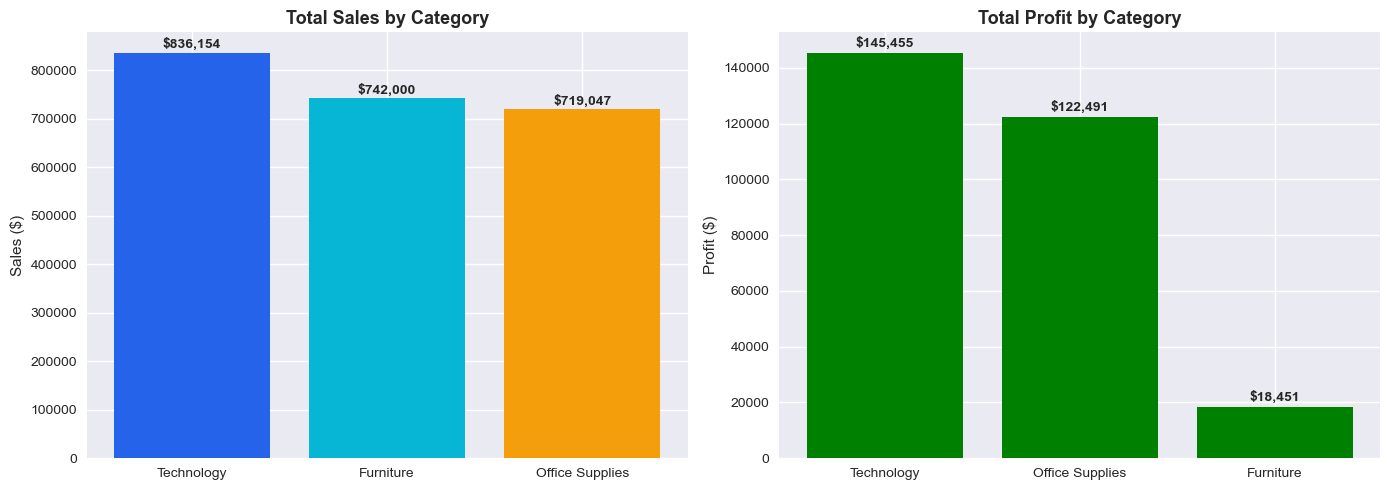

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales by category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0].bar(cat_sales.index, cat_sales.values, color=['#2563eb','#06b6d4','#f59e0b'])
axes[0].set_title('Total Sales by Category', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Sales ($)')
for i, v in enumerate(cat_sales.values):
    axes[0].text(i, v + 10000, f'${v:,.0f}', ha='center', fontweight='bold')

# Profit by category
cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
colors = ['green' if x > 0 else 'red' for x in cat_profit.values]
axes[1].bar(cat_profit.index, cat_profit.values, color=colors)
axes[1].set_title('Total Profit by Category', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Profit ($)')
for i, v in enumerate(cat_profit.values):
    axes[1].text(i, v + 2000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

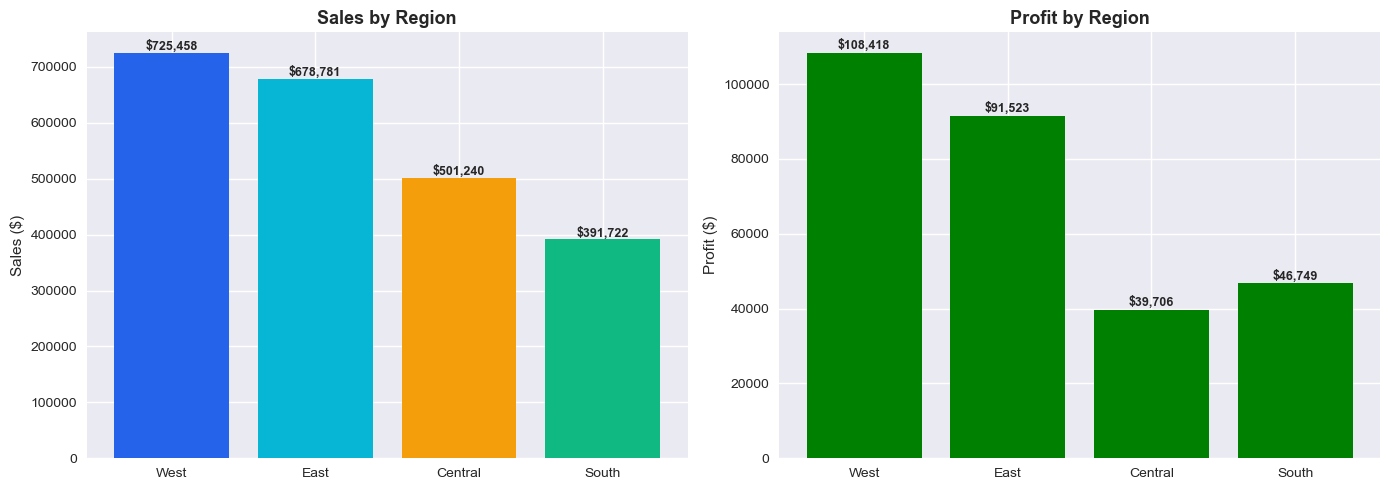

             Sales     Profit
Region                       
West     725457.82  108418.45
East     678781.24   91522.78
Central  501239.89   39706.36
South    391721.90   46749.43


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_data = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)

# Sales by region
axes[0].bar(region_data.index, region_data['Sales'], color=['#2563eb','#06b6d4','#f59e0b','#10b981'])
axes[0].set_title('Sales by Region', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Sales ($)')
for i, v in enumerate(region_data['Sales']):
    axes[0].text(i, v + 5000, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)

# Profit by region
colors = ['green' if x > 0 else 'red' for x in region_data['Profit']]
axes[1].bar(region_data.index, region_data['Profit'], color=colors)
axes[1].set_title('Profit by Region', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Profit ($)')
for i, v in enumerate(region_data['Profit']):
    axes[1].text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
print(region_data.round(2))

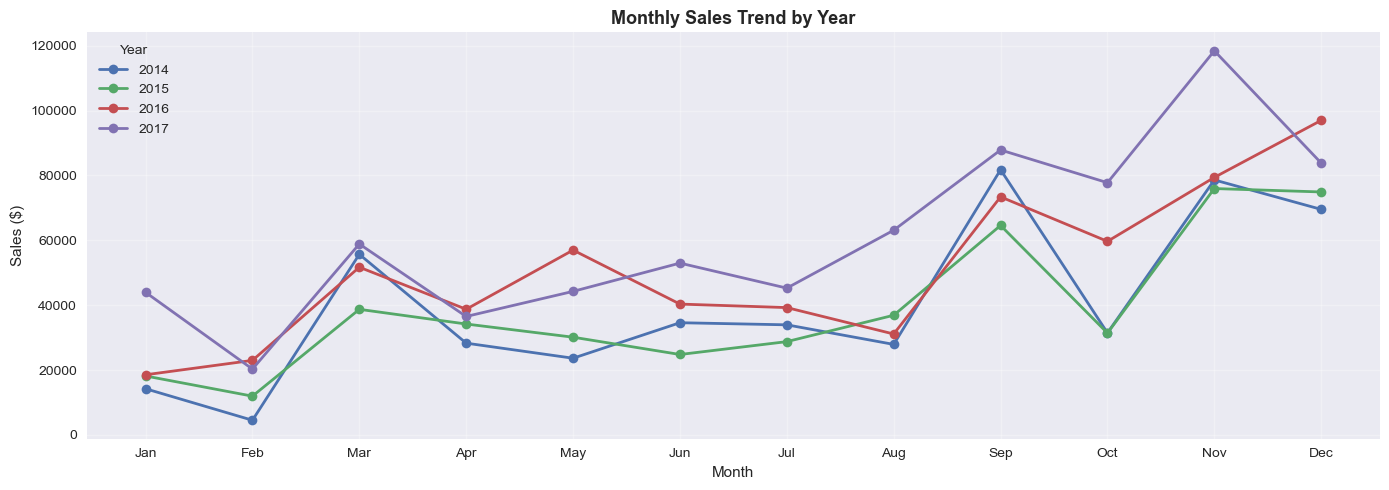

In [13]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year','Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
for year in monthly_sales['Year'].unique():
    data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(data['Month'], data['Sales'], marker='o', label=str(year), linewidth=2)

plt.title('Monthly Sales Trend by Year', fontweight='bold', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

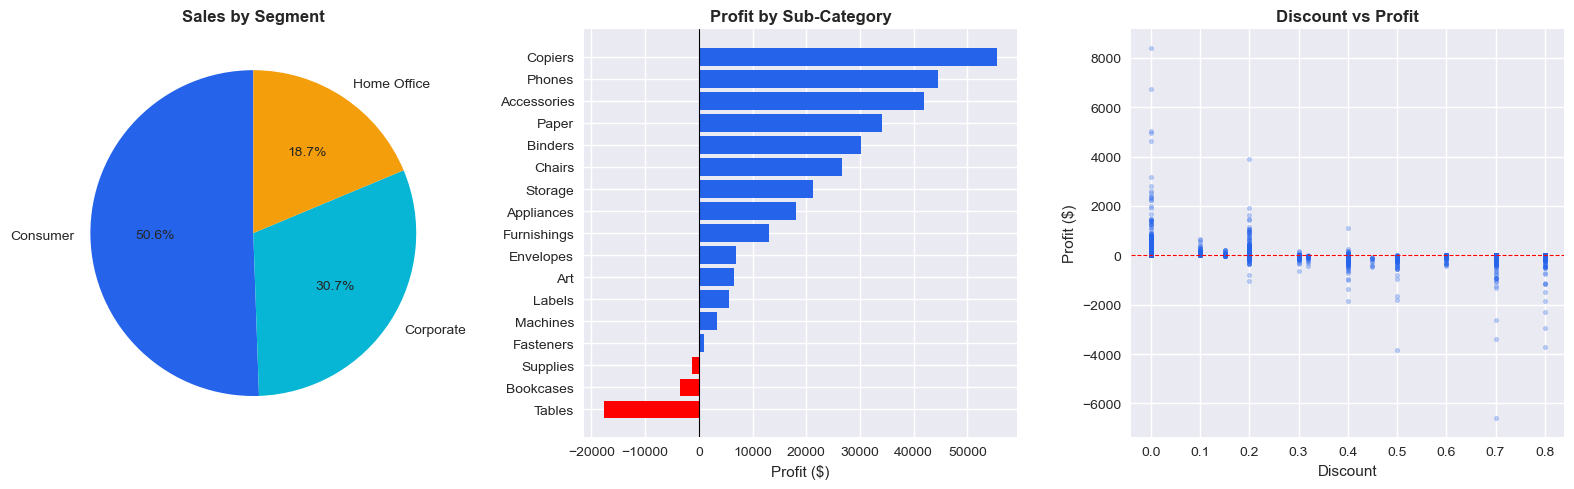

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sales by segment
seg = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
axes[0].pie(seg.values, labels=seg.index, autopct='%1.1f%%',
            colors=['#2563eb','#06b6d4','#f59e0b'], startangle=90)
axes[0].set_title('Sales by Segment', fontweight='bold')

# Profit by sub-category (top 10)
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=True)
colors = ['red' if x < 0 else '#2563eb' for x in sub_profit.values]
axes[1].barh(sub_profit.index, sub_profit.values, color=colors)
axes[1].set_title('Profit by Sub-Category', fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].axvline(x=0, color='black', linewidth=0.8)

# Discount vs Profit scatter
axes[2].scatter(df['Discount'], df['Profit'], alpha=0.3, color='#2563eb', s=10)
axes[2].set_title('Discount vs Profit', fontweight='bold')
axes[2].set_xlabel('Discount')
axes[2].set_ylabel('Profit ($)')
axes[2].axhline(y=0, color='red', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

In [17]:
print("=" * 55)
print("       SUPERSTORE BUSINESS INSIGHTS SUMMARY")
print("=" * 55)

print(f"\n📦 OVERALL PERFORMANCE")
print(f"   Total Sales:     ${df['Sales'].sum():>12,.2f}")
print(f"   Total Profit:    ${df['Profit'].sum():>12,.2f}")
print(f"   Profit Margin:    {df['Profit'].sum()/df['Sales'].sum()*100:.2f}%")

print(f"\n🏆 BEST PERFORMING")
print(f"   Top Region:     {df.groupby('Region')['Profit'].sum().idxmax()}")
print(f"   Top Category:   {df.groupby('Category')['Profit'].sum().idxmax()}")
print(f"   Top Sub-Cat:    {df.groupby('Sub-Category')['Profit'].sum().idxmax()}")

print(f"\n⚠️  LOSS-MAKING SUB-CATEGORIES")
loss = df.groupby('Sub-Category')['Profit'].sum()
for name, val in loss[loss < 0].items():
    print(f"   {name:<15} ${val:>10,.2f}")

print(f"\n📅 SEASONAL PATTERN")
monthly = df.groupby('Month')['Sales'].mean()
print(f"   Peak Month:     {monthly.idxmax()} ({['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][monthly.idxmax()-1]})")
print(f"   Lowest Month:   {monthly.idxmin()} ({['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][monthly.idxmin()-1]})")

print(f"\n💡 KEY RECOMMENDATIONS")
print(f"   1. Reduce discounts above 30% — directly causes losses")
print(f"   2. Review Tables & Bookcases pricing strategy")
print(f"   3. Invest more in Copiers & Phones — highest profit")
print(f"   4. Focus Q4 campaigns (Sep-Nov) — peak sales season")
print("=" * 55)

       SUPERSTORE BUSINESS INSIGHTS SUMMARY

📦 OVERALL PERFORMANCE
   Total Sales:     $2,297,200.86
   Total Profit:    $  286,397.02
   Profit Margin:    12.47%

🏆 BEST PERFORMING
   Top Region:     West
   Top Category:   Technology
   Top Sub-Cat:    Copiers

⚠️  LOSS-MAKING SUB-CATEGORIES
   Bookcases       $ -3,472.56
   Supplies        $ -1,189.10
   Tables          $-17,725.48

📅 SEASONAL PATTERN
   Peak Month:     3 (Mar)
   Lowest Month:   2 (Feb)

💡 KEY RECOMMENDATIONS
   1. Reduce discounts above 30% — directly causes losses
   2. Review Tables & Bookcases pricing strategy
   3. Invest more in Copiers & Phones — highest profit
   4. Focus Q4 campaigns (Sep-Nov) — peak sales season
